### The following libraries are required to run the code.
1. RetinaFace: `pip install retinaface` [pypi](https://pypi.org/project/retina-face/)
2. DeepFace: `pip install deepface`  [pypi](https://pypi.org/project/deepface/)
3. Tensorflow: `pip install tf-keras`

In [1]:
""" Uncomment the following lines and hit `Ctr+Enter` to install them. """

!pip install retinaface
!pip install deepface
!pip install tf-keras

INFO: pip is looking at multiple versions of retinaface to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of retinaface to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install retinaface==0.0.1, retinaface==0.0.2, retinaface==0.0.3, retinaface==0.0.4, retinaface==0.0.5, retinaface==0.0.6, retinaface==1.1.0 and retinaface==1.1.1 because these package versions have conflicting dependencies.

The conflict is caused by:
    retinaface 1.1.1 depends on tensorflow==2.5.0
    retinaface 1.1.0 depends on tensorflow==2.5.0
    retinaface 0.0.6 depends on tensorflow==2.1.0
    retinaface 0.0.5 depends on tensorflow==2.1.0
    retinaface 0.0.4 depends on tensorflow==2.1.0
    retinaface 0.0.3 depends on tensorflow==2.1.0
    retinaface 0.0.2 depends on tensorflow==2.1.0
    retinaface 0.0.1 depends on tensorflow==2.1.0

To fix this you could try to:
1. 

In [34]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Face detection and recognition models
from deepface import DeepFace # It's  a deepface full package that contains both detection and recognition of faces with more alternative models (tasks)
from retinaface import RetinaFace # This is the model for face detection which is adopted in this code.

## Face Detection using `RetinaFace` Model
1. Read the input image for detection

2. Detect Faces and Facial landmarks
3. Visualize detected faces along with facial landmarks

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [8]:
## unpacking compressed (archived) image collection
!cd /content/drive/MyDrive/COSC330; unzip Archive.zip


Archive:  Archive.zip
   creating: FacesFramed/
  inflating: FacesFramed/Brad Pitt_42.jpg  
  inflating: FacesFramed/Ellen Degeneres_64.jpg  
  inflating: FacesFramed/Natalie Portman_102.jpg  
  inflating: FacesFramed/Ellen Degeneres_70.jpg  
  inflating: FacesFramed/Brad Pitt_56.jpg  
  inflating: FacesFramed/Ellen Degeneres_58.jpg  
  inflating: FacesFramed/Tom Cruise_0.jpg  
  inflating: FacesFramed/Billie Eilish_7.jpg  
  inflating: FacesFramed/Brad Pitt_81.jpg  
  inflating: FacesFramed/Billie Eilish_14.jpg  
  inflating: FacesFramed/Brad Pitt_95.jpg  
  inflating: FacesFramed/Alexandra Daddario_37.jpg  
  inflating: FacesFramed/Billie Eilish_28.jpg  
  inflating: FacesFramed/Alexandra Daddario_23.jpg  
  inflating: FacesFramed/Tom Cruise_54.jpg  
  inflating: FacesFramed/Courtney Cox_0.jpg  
  inflating: FacesFramed/Tom Cruise_40.jpg  
  inflating: FacesFramed/Alia Bhatt_9.jpg  
  inflating: FacesFramed/Zac Efron_22.jpg  
  inflating: FacesFramed/Marmik_18.jpg  
  inflating: Face

In [18]:
dataset_meta = '/content/drive/MyDrive/COSC330/Dataset.csv'
import pandas as pd

df = pd.read_csv(dataset_meta)
df.head()

,id,label
0,Robert Downey Jr_87.jpg,Robert Downey Jr
1,Lisa Kudrow_64.jpg,Lisa Kudrow
2,Ellen Degeneres_34.jpg,Ellen Degeneres
3,Billie Eilish_3.jpg,Billie Eilish
4,Hrithik Roshan_35.jpg,Hrithik Roshan


In [20]:
df.value_counts("label")
for artist, dfa in df.groupby("label"):
  break
dfa.sample(frac=0.8).head()

,id,label
1957,Akshay Kumar_17.jpg,Akshay Kumar
1340,Akshay Kumar_14.jpg,Akshay Kumar
941,Akshay Kumar_27.jpg,Akshay Kumar
1283,Akshay Kumar_46.jpg,Akshay Kumar
756,Akshay Kumar_3.jpg,Akshay Kumar


In [23]:
dfa.sample(frac=.8).shape

(40, 2)

In [25]:
# prompt: give a function that creates a train-test set from the dataframe df, downsampling each label to a specified percentage for the train set and taking the rest as test set

def create_train_test_set(df, downsample_percentage=0.8):
  """
  Creates train and test sets from a dataframe, downsampling each label for the train set.

  Args:
      df: The input DataFrame with a 'label' column.
      downsample_percentage: The percentage of each label to include in the train set (default is 0.8).

  Returns:
      A tuple containing the train and test DataFrames.
  """
  train_df = pd.DataFrame()
  test_df = pd.DataFrame()

  for label, group in df.groupby('label'):
      # Sample the group for the train set
      train_group = group.sample(frac=downsample_percentage, random_state=42)  # Use a random state for reproducibility

      # Add the train samples to the train set
      train_df = pd.concat([train_df, train_group], ignore_index=True)

      # Add the rest to the test set
      test_df = pd.concat([test_df, group.drop(train_group.index)], ignore_index=True)

  return train_df, test_df


In [26]:
train_df, test_df = create_train_test_set(df)

In [27]:
print(train_df.shape, test_df.shape)

(2051, 2) (511, 2)


In [32]:
test_df[test_df.label=="Brad Pitt"].shape

(24, 2)

In [ ]:

img_path = "/content/drive/MyDrive/Colab Notebooks/lab_image2.png" # put you own path

# """Read the image """
img = cv2.imread(img_path)
print(f'Input image shape: {img.shape}') # (H, W, Channel)

Input image shape: (765, 1221, 3)


In [ ]:
""" Run Face detection """
detected_faces = RetinaFace.detect_faces(
    img_path=img_path,
    threshold=0.9,
)

print(f"Detected faces: {detected_faces}")
print(f"Total Faces: {len(detected_faces.keys())}")
print(f"Faces: {detected_faces.keys()}")

25-01-24 04:48:49 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:00<00:00, 220MB/s]


Detected faces: {'face_1': {'score': 0.9988929033279419, 'facial_area': [297, 243, 322, 273], 'landmarks': {'right_eye': [309.55457, 254.70265], 'left_eye': [319.59872, 252.53217], 'nose': [319.1921, 259.44406], 'mouth_right': [313.66678, 266.70367], 'mouth_left': [320.69867, 265.274]}}, 'face_2': {'score': 0.9987869262695312, 'facial_area': [638, 410, 674, 454], 'landmarks': {'right_eye': [656.85895, 428.67856], 'left_eye': [670.4955, 427.2347], 'nose': [668.015, 437.71875], 'mouth_right': [658.02484, 445.72812], 'mouth_left': [667.34326, 445.00006]}}, 'face_3': {'score': 0.9987401366233826, 'facial_area': [733, 194, 758, 225], 'landmarks': {'right_eye': [741.026, 204.55135], 'left_eye': [752.408, 204.3613], 'nose': [747.1675, 210.86047], 'mouth_right': [742.40393, 217.28084], 'mouth_left': [751.29443, 217.1462]}}, 'face_4': {'score': 0.9982625842094421, 'facial_area': [457, 221, 481, 250], 'landmarks': {'right_eye': [468.23032, 234.7538], 'left_eye': [477.58243, 232.76663], 'nose': [

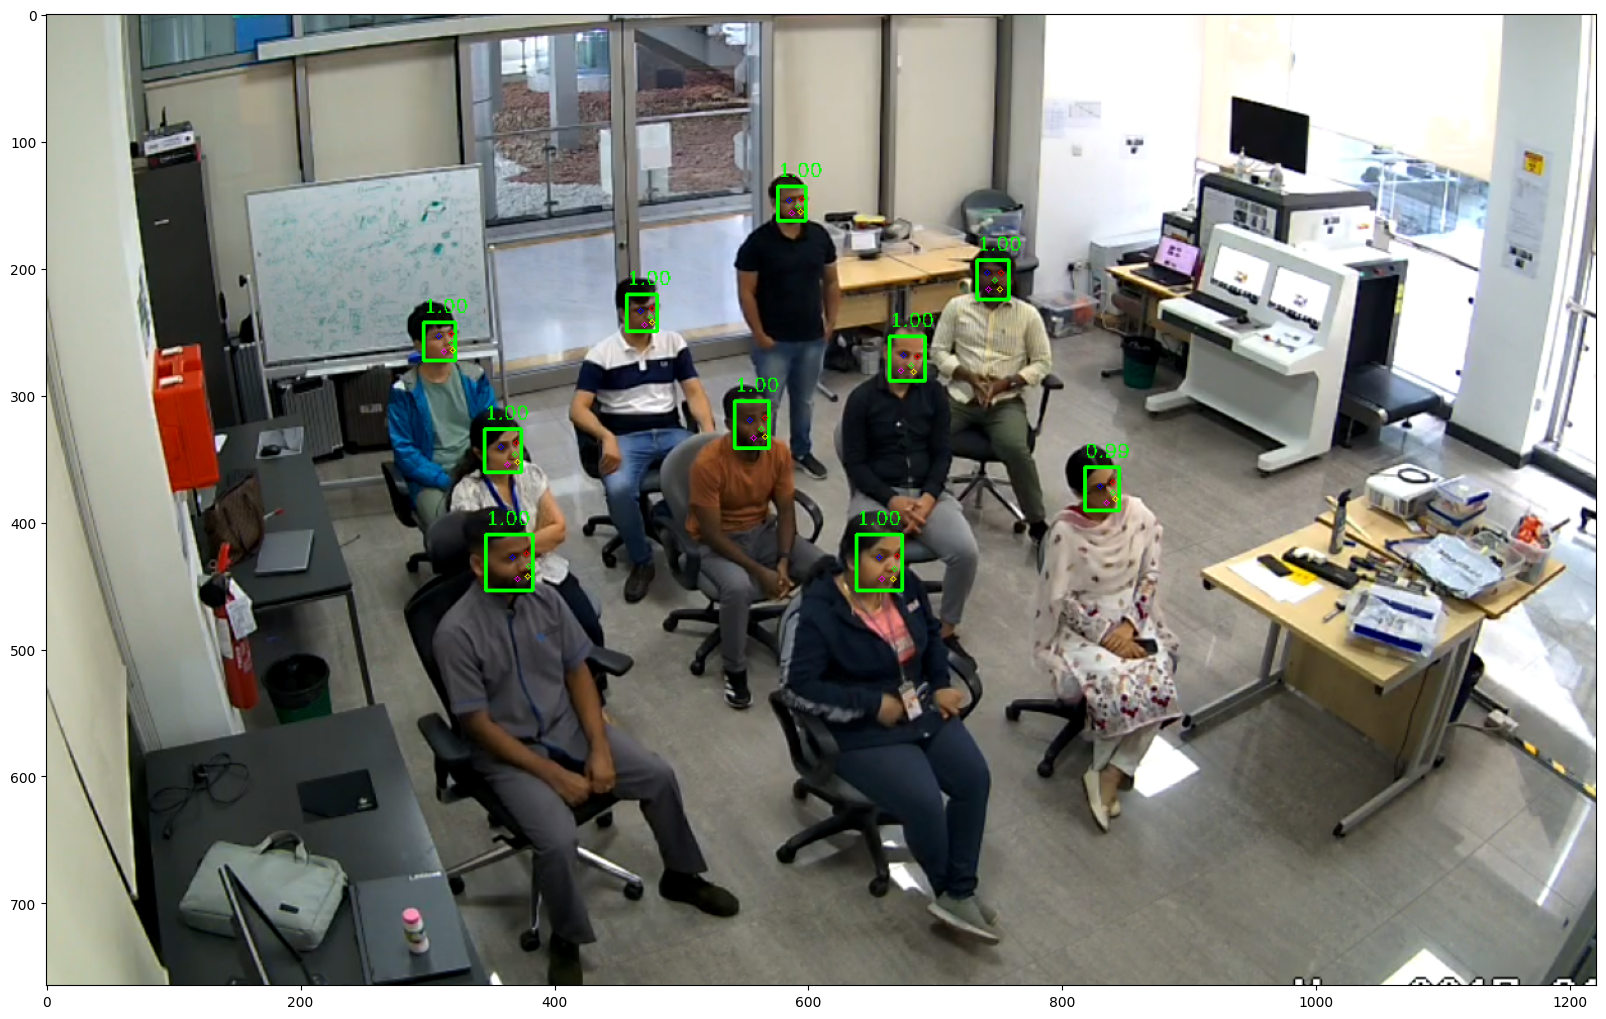

In [ ]:
def visualize(detected_faces):
    """ Define colors for facial landmarks """
    landmark_color = [
        (255,   0,   0), # right eye
        (  0,   0, 255), # left eye
        (  0, 255,   0), # nose tip
        (255,   0, 255), # right mouth corner
        (  0, 255, 255)  # left mouth corner
    ]

    for key in detected_faces.keys():
        identity = detected_faces[key] # identity: {'score': 0.9992936849594116, 'facial_area': [710, 240, 735, 270], 'landmarks': {'right_eye': [721.69055, 253.59639], 'left_eye': [732.4018, 252.42545], 'nose': [729.3393, 259.64685], 'mouth_right': [722.98773, 264.2315], 'mouth_left': [731.3062, 263.6203]}}
        facial_area = identity['facial_area']
        score = identity['score']
        landmarks = identity['landmarks'] # landmarks: {'right_eye': [721.69055, 253.59639], 'left_eye': [732.4018, 252.42545], 'nose': [729.3393, 259.64685], 'mouth_right': [722.98773, 264.2315], 'mouth_left': [731.3062, 263.6203]}

        # Draw rectangle for facial area
        cv2.rectangle(
            img,
            (facial_area[0], facial_area[1]),  # Top-left corner
            (facial_area[2], facial_area[3]),  # Bottom-right corner
            (0, 255, 0), 2
        )

        # Draw confidence score
        cv2.putText(
            img,
            '{:.2f}'.format(score),  # Corrected format string
            (facial_area[0], facial_area[1] - 8),
            cv2.FONT_HERSHEY_COMPLEX,
            0.5,
            (0, 255, 0)
        )
        # cv2.putText(img, '{:.2f}'.format(score), (facial_area[2], facial_area[3]-5), cv2.FONT_HERSHEY_COMPLEX, 0.5, (0, 255, 0))

        for idx, (_, v) in enumerate(landmarks.items()): # v: [731.3062, 263.6203] floating list
            cv2.circle(
                img,
                center=tuple(map(int, v)),  # Convert to integer tuple
                radius=2,
                color=landmark_color[idx],
                thickness=1
            )
        # break

    plt.figure(figsize=(20, 20))
    plt.imshow(img[:, :, ::-1])
    plt.show()

visualize(detected_faces)

### Face Embedding (Signature) Generation using DeepFace models, such as ArcFace, SFace, etc.
1. Extract Aligned and Cropped Faces with the RetinaFace model
2. Extract faces using the RetinaFace
3. Visualize faces
4. Generate face embeddings

In [36]:
# prompt: use the deepface library to create embeddings of the files that are listed in the train_df (column id). Don't forget to prepend the folder name ('/content/drive/MyDrive/COSC330/')

import os
from deepface import DeepFace

def generate_embeddings(df, folder_name):
    embeddings = []
    for index, row in df.iterrows():
        img_path = os.path.join(folder_name, row['id'])
        try:
            embedding = DeepFace.represent(img_path=img_path, model_name='ArcFace')
            embeddings.append(embedding[0]["embedding"])
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            embeddings.append(None) # Append None for images that cause errors
    return embeddings


folder_name = '/content/drive/MyDrive/COSC330/FacesFramed'
train_embeddings = generate_embeddings(train_df, folder_name)
train_df['embeddings'] = train_embeddings


Error processing /content/drive/MyDrive/COSC330/FacesFramed/Akshay Kumar_20.jpg: Face could not be detected in /content/drive/MyDrive/COSC330/FacesFramed/Akshay Kumar_20.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error processing /content/drive/MyDrive/COSC330/FacesFramed/Akshay Kumar_14.jpg: Face could not be detected in /content/drive/MyDrive/COSC330/FacesFramed/Akshay Kumar_14.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error processing /content/drive/MyDrive/COSC330/FacesFramed/Alia Bhatt_52.jpg: Face could not be detected in /content/drive/MyDrive/COSC330/FacesFramed/Alia Bhatt_52.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error processing /content/drive/MyDrive/COSC330/FacesFramed/Alia Bhatt_14.jpg: Face could not be detected in /content/drive/MyDrive/COSC330/FacesFramed/Alia Bhatt_14.jpg.Please co

In [39]:
train_embeddings.count(None)

157

In [40]:
test_embeddings = generate_embeddings(test_df, folder_name)
test_df['embeddings'] = test_embeddings

Error processing /content/drive/MyDrive/COSC330/FacesFramed/Akshay Kumar_11.jpg: Face could not be detected in /content/drive/MyDrive/COSC330/FacesFramed/Akshay Kumar_11.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error processing /content/drive/MyDrive/COSC330/FacesFramed/Alexandra Daddario_27.jpg: Face could not be detected in /content/drive/MyDrive/COSC330/FacesFramed/Alexandra Daddario_27.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error processing /content/drive/MyDrive/COSC330/FacesFramed/Alia Bhatt_56.jpg: Face could not be detected in /content/drive/MyDrive/COSC330/FacesFramed/Alia Bhatt_56.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error processing /content/drive/MyDrive/COSC330/FacesFramed/Alia Bhatt_40.jpg: Face could not be detected in /content/drive/MyDrive/COSC330/FacesFramed/Alia Bhatt_40.j

In [ ]:
import numpy as np
#from np.linalg import norm

v1 = np.array([1,2,3])
v2 = np.array([1,2,4])

np.linalg.norm(v1-v2)

1.0

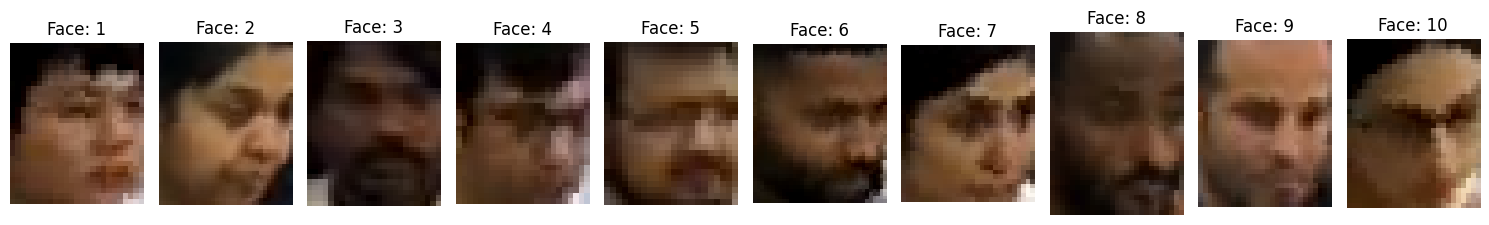

25-01-20 12:49:00 - arcface_weights.h5 will be downloaded to /root/.deepface/weights/arcface_weights.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5
100%|██████████| 137M/137M [00:01<00:00, 73.8MB/s]


Signatures: (512,)
Signatures: (512,)
Signatures: (512,)
Signatures: (512,)
Signatures: (512,)
Signatures: (512,)
Signatures: (512,)
Signatures: (512,)
Signatures: (512,)
Signatures: (512,)


In [ ]:
faces = RetinaFace.extract_faces(img_path)
n = len(faces)

plt.figure(figsize=(15, 5))
for i, f in enumerate(faces):
    # print(f'f: {f.shape}')
    plt.subplot(1, n, i + 1)
    plt.imshow(f)
    plt.axis('off')
    plt.title(f"Face: {i + 1}")
plt.tight_layout()
plt.show()

for face in faces:
    signatures = DeepFace.represent(
        img_path=face,
        model_name="ArcFace", # Options: VGG-Face, Facenet, Facenet512, OpenFace, DeepFace, DeepID, Dlib, ArcFace, SFace and GhostFaceNet
        enforce_detection=False,
    )

    embeddings = np.array(signatures[0]["embedding"]) # 512-dimensional face features
    score = signatures[0]['face_confidence']

    print(f'Signatures: {embeddings.shape}')


### Query Face Embedding with Detected Faces
1. Extract faces from the query image
2. Generate embeddings for the query image
3. Compare the Query Face Embedding with Detected Faces

In [ ]:
!python --version

Python 3.11.11


In [ ]:

from numpy.linalg import norm

#query_img = cv2.imread("/content/drive/MyDrive/Research/Code/FaceRecognition/Images/S_001.jpg") # put you own patht

# Cosine similarity
def compute_similarity(embedding1, embedding2):
    return np.dot(embedding1, embedding2) / (norm(embedding1) * norm(embedding2))

compute_similarity(v1, v1)

1.0

In [ ]:
from numpy.linalg import norm

query_img = cv2.imread("/content/drive/MyDrive/Research/Code/FaceRecognition/Images/S_001.jpg") # put you own patht

# Cosine similarity
def compute_similarity(embedding1, embedding2):
    return np.dot(embedding1, embedding2) / (norm(embedding1) * norm(embedding2))

# Step 1: Extract query face and generate its embedding
query_faces = RetinaFace.extract_faces(query_img)
if len(query_faces) == 0:
    print(f"No faces detected in the query image.")

# Let's use the first detected face as the query face if detected
query_face = query_faces[0]

# Step 2: Generate embedding for the query face
query_signature = DeepFace.represent(
    query_face,
    model_name='ArcFace',
    enforce_detection=False
)

query_embedding = np.array(query_signature[0]['embedding']) # a 512-dimensional embedding
print(f"query_embedding: {query_embedding.shape}")
print(f"query score: {query_signature[0]['face_confidence']}")

# Step 3: Compare query face embedding with all detected faces
similarities = []
for i, face in enumerate(faces):
    # Generate embedding for each detected face
    face_signature = DeepFace.represent(
        img_path=face,
        model_name="ArcFace",
        enforce_detection=False,
    )
    face_embedding = np.array(face_signature[0]["embedding"])

    # Compute similarity
    similarity = compute_similarity(query_embedding, face_embedding)
    similarities.append((i + 1, similarity))

    print(f"Face {i + 1}: Similarity with query face: {similarity:.4f}")

# Step 4: Sort faces by similarity
similarities = sorted(similarities, key=lambda x: x[1], reverse=True)  # Higher is more similar for cosine

print("Similarity scores:", similarities)


query_embedding: (512,)
query score: 0.93
Face 1: Similarity with query face: 0.0478
Face 2: Similarity with query face: 0.0190
Face 3: Similarity with query face: 0.0867
Face 4: Similarity with query face: 0.0394
Face 5: Similarity with query face: 0.0447
Face 6: Similarity with query face: 0.1062
Face 7: Similarity with query face: 0.0035
Face 8: Similarity with query face: 0.1503
Face 9: Similarity with query face: 0.1032
Face 10: Similarity with query face: 0.0223
Similarity scores: [(8, 0.1502964152358529), (6, 0.10623620965917219), (9, 0.10316338745976579), (3, 0.08674782056141467), (1, 0.04781548858875875), (5, 0.04471172081105287), (4, 0.03935634165134041), (10, 0.022335271534959213), (2, 0.019030912604546743), (7, 0.003476216642897263)]
